In [1]:
import kagglehub
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

kagglehub.dataset_download("shivamb/netflix-shows")
df = pd.read_csv("../../datasets/netflix_titles.csv")


In [2]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [4]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [5]:
df["director"] = df["director"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["rating"] = df["rating"].fillna("Unknown")
df["duration"] = df["duration"].fillna("Unknown")
df = df.dropna(subset=["date_added"])
df.isnull().sum()


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [6]:
df["date_added"] = pd.to_datetime(df["date_added"].str.strip())
df[["title", "date_added"]].info()


<class 'pandas.DataFrame'>
Index: 8797 entries, 0 to 8806
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   title       8797 non-null   str           
 1   date_added  8797 non-null   datetime64[us]
dtypes: datetime64[us](1), str(1)
memory usage: 206.2 KB


In [7]:
df.columns = df.columns.str.strip()
print("Cleaned Column Names:", list(df.columns))


Cleaned Column Names: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


/tmp/ipykernel_20007/2202121458.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="type", palette="viridis")


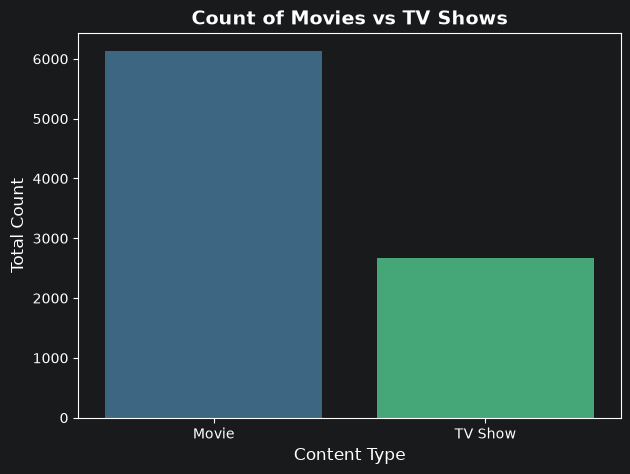

In [8]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="type", palette="viridis")
plt.title("Count of Movies vs TV Shows", fontsize=14, fontweight="bold")
plt.xlabel("Content Type", fontsize=12)
plt.ylabel("Total Count", fontsize=12)
plt.show()


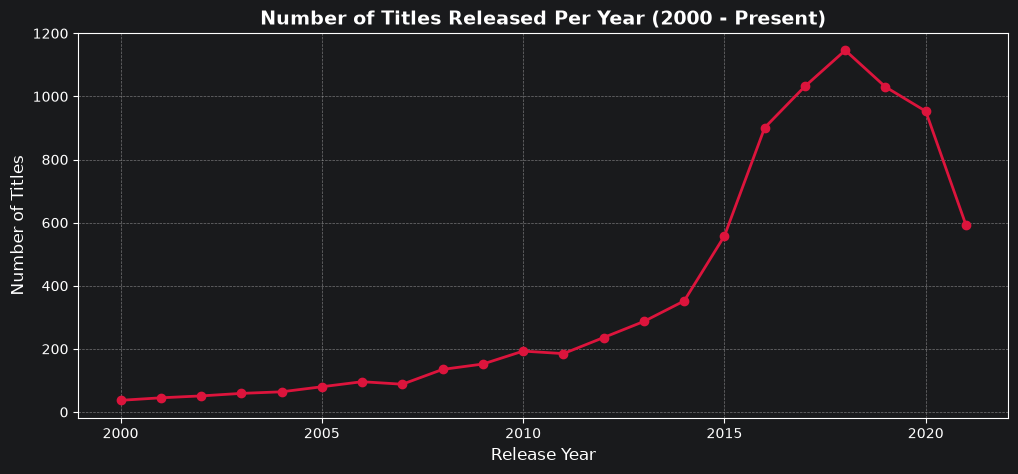

In [9]:
yearly_counts = df[df["release_year"] >= 2000]["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(yearly_counts.index, yearly_counts.values, marker="o", color="crimson", linewidth=2)
plt.title("Number of Titles Released Per Year (2000 - Present)", fontsize=14, fontweight="bold")
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Number of Titles", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


/tmp/ipykernel_20007/2549028960.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top10_countries.values, y=top10_countries.index, palette="mako")


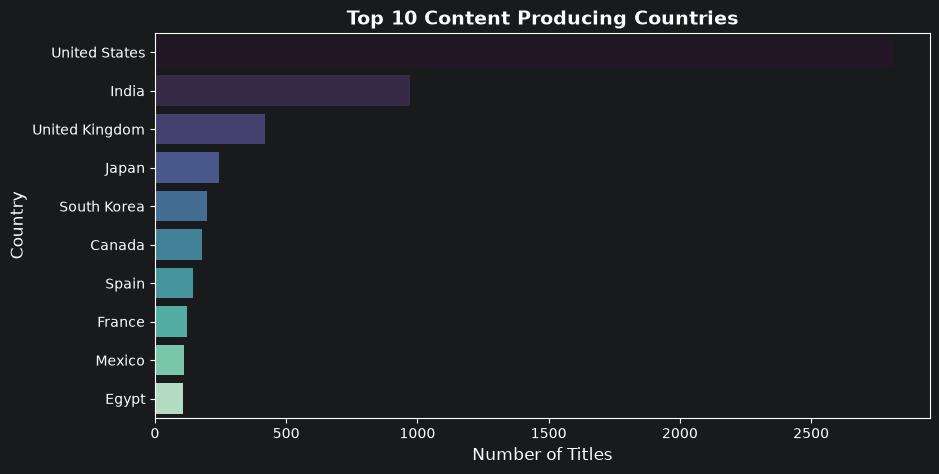

In [10]:
top10_countries = df[df["country"] != "Unknown"]["country"].value_counts().head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=top10_countries.values, y=top10_countries.index, palette="mako")
plt.title("Top 10 Content Producing Countries", fontsize=14, fontweight="bold")
plt.xlabel("Number of Titles", fontsize=12)
plt.ylabel("Country", fontsize=12)
plt.show()
